## 1. Setup and Configuration

In [2]:
import os
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# =============================================================================
# DIRECTORY PATHS
# =============================================================================
CODE_DIR = Path(r"c:\Users\skazempour\Dropbox\Projects\42 - Machine learning from the crowd\Code")
DATA_DIR = Path(r"c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\csv")

# Input: Merged StockTwits-CRSP data by year
INPUT_FOLDER = DATA_DIR / "merged_with_crsp_mlcrowd"

# Output: Features (consolidated pickle files)
OUTPUT_FOLDER = DATA_DIR / "features_mlcrowd"
OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

OUTPUT_FILE = OUTPUT_FOLDER / "features_02_volume_attention.pkl"

# =============================================================================
# PARAMETERS
# =============================================================================
HORIZONS = [5, 21, 63, 250]  # Standardized horizons from feature_proposal.md

print(f"Input folder: {INPUT_FOLDER}")
print(f"Output folder: {OUTPUT_FOLDER}")
print(f"Output file: {OUTPUT_FILE}")
print(f"Horizons: {HORIZONS}")

Input folder: c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\csv\merged_with_crsp_mlcrowd
Output folder: c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\csv\features_mlcrowd
Output file: c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\csv\features_mlcrowd\features_02_volume_attention.pkl
Horizons: [5, 21, 63, 250]


## 2. Load Trading Day Calendar from Fama-French Data

In [3]:
# Download Fama-French daily factors to get official trading day calendar
# This ensures we have all CRSP trading days, even if no tweets occurred
import pandas_datareader as pdr

print("Loading Fama-French data for trading day calendar...")
try:
    # Download FF3 daily factors (has all trading days)
    ff_data = pdr.data.DataReader('F-F_Research_Data_Factors_daily', 'famafrench', start='2010')[0]
    
    # Extract trading days
    ALL_TRADING_DAYS = pd.to_datetime(ff_data.index)
    print(f"✓ Loaded {len(ALL_TRADING_DAYS):,} trading days from Fama-French")
    print(f"  Date range: {ALL_TRADING_DAYS.min()} to {ALL_TRADING_DAYS.max()}")
    
except Exception as e:
    print(f"Warning: Could not download FF data: {e}")
    print("Will extract trading days from CRSP-merged data instead")
    ALL_TRADING_DAYS = None

Loading Fama-French data for trading day calendar...


C:\Users\skazempour\AppData\Local\Temp\ipykernel_11452\2822927898.py:8: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff_data = pdr.data.DataReader('F-F_Research_Data_Factors_daily', 'famafrench', start='2010')[0]


✓ Loaded 3,983 trading days from Fama-French
  Date range: 2010-01-04 00:00:00 to 2025-10-31 00:00:00


## 3. Load Sample Data for Development

In [4]:
# Get list of available files
files = sorted([f for f in os.listdir(INPUT_FOLDER) if f.endswith('.csv')])
print(f"Available files: {len(files)}")
print(f"Files: {files}")

# Load most recent year for development
if files:
    sample_file = INPUT_FOLDER / files[-1]
    print(f"\nLoading sample file for testing: {sample_file.name}")
    
    df_sample = pd.read_csv(sample_file)
    df_sample['date'] = pd.to_datetime(df_sample['date'])
    df_sample['created_at'] = pd.to_datetime(df_sample['created_at'])
    
    print(f"\nShape: {df_sample.shape}")
    print(f"Date range: {df_sample['date'].min()} to {df_sample['date'].max()}")
    print(f"Unique symbols: {df_sample['symbol'].nunique():,}")
    print(f"Unique users: {df_sample['user_id'].nunique():,}")

Available files: 15
Files: ['stocktwits_crsp_2010.csv', 'stocktwits_crsp_2011.csv', 'stocktwits_crsp_2012.csv', 'stocktwits_crsp_2013.csv', 'stocktwits_crsp_2014.csv', 'stocktwits_crsp_2015.csv', 'stocktwits_crsp_2016.csv', 'stocktwits_crsp_2017.csv', 'stocktwits_crsp_2018.csv', 'stocktwits_crsp_2019.csv', 'stocktwits_crsp_2020.csv', 'stocktwits_crsp_2021.csv', 'stocktwits_crsp_2022.csv', 'stocktwits_crsp_2023.csv', 'stocktwits_crsp_2024.csv']

Loading sample file for testing: stocktwits_crsp_2024.csv

Shape: (7247, 40)
Date range: 2024-01-02 00:00:00 to 2024-01-03 00:00:00
Unique symbols: 1,043
Unique users: 3,660


## 3. Define Feature Calculation Functions

In [5]:
def calculate_volume_attention_features(df, horizons=HORIZONS, trading_days=None):
    """
    Calculate volume and attention features for each stock-day.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Merged StockTwits-CRSP data with columns: symbol, date, user_id, created_at
    horizons : list
        List of horizons for rolling calculations
    trading_days : pd.DatetimeIndex, optional
        Official trading day calendar (from Fama-French). If None, extracted from data.
        
    Returns:
    --------
    pd.DataFrame: Stock-day level volume and attention features
    """
    # Ensure date is datetime
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    if 'created_at' in df.columns:
        df['created_at'] = pd.to_datetime(df['created_at'])
    
    # Group by symbol and date for basic aggregations
    grouped = df.groupby(['symbol', 'date'])
    
    # =============================================================================
    # BASIC VOLUME FEATURES (28-30)
    # =============================================================================
    
    # 28. Raw Volume: Tweet count per stock-day
    volume_features = grouped.size().rename('raw_volume').reset_index()
    
    # 29. Log Volume
    volume_features['log_volume'] = np.log1p(volume_features['raw_volume'])
    
    # 30. Unique User Count
    unique_users = grouped['user_id'].nunique().rename('unique_user_count').reset_index()
    volume_features = volume_features.merge(unique_users, on=['symbol', 'date'])
    
    # =============================================================================
    # CREATE COMPLETE TRADING DAY GRID
    # Uses Fama-French trading calendar for accurate rolling windows
    # =============================================================================
    
    print(f"  Creating complete trading day grid...")
    
    # Use provided trading days or extract from data
    if trading_days is not None:
        # Filter to date range in the data
        data_start = df['date'].min()
        data_end = df['date'].max()
        all_trading_days = trading_days[(trading_days >= data_start) & (trading_days <= data_end)]
        print(f"    Using Fama-French calendar: {len(all_trading_days)} trading days")
    else:
        # Fallback: extract from data
        all_trading_days = sorted(df['date'].unique())
        print(f"    Using data-derived calendar: {len(all_trading_days)} days")
    
    # Get all symbols that appear in the data
    all_symbols = volume_features['symbol'].unique()
    print(f"    Symbols: {len(all_symbols)}")
    
    # Create complete grid of (symbol, trading_day) combinations
    complete_grid = pd.MultiIndex.from_product(
        [all_symbols, all_trading_days],
        names=['symbol', 'date']
    ).to_frame(index=False)
    print(f"    Grid size: {len(complete_grid):,} rows")
    
    # Store original data indicators for filtering later
    volume_features['has_data'] = True
    
    # Merge with actual volume data, filling missing with 0
    volume_features = complete_grid.merge(
        volume_features,
        on=['symbol', 'date'],
        how='left'
    )
    
    # Fill missing values with 0 for volume-based features
    volume_features['raw_volume'] = volume_features['raw_volume'].fillna(0)
    volume_features['log_volume'] = volume_features['log_volume'].fillna(0)
    volume_features['unique_user_count'] = volume_features['unique_user_count'].fillna(0)
    volume_features['has_data'] = volume_features['has_data'].fillna(False)
    
    # =============================================================================
    # VOLUME CHANGES (31-32)
    # =============================================================================
    
    # Sort by symbol and date for lag calculations
    volume_features = volume_features.sort_values(['symbol', 'date'])
    
    # 31. Volume Difference: V_t - V_{t-1}
    volume_features['volume_diff'] = volume_features.groupby('symbol')['raw_volume'].diff()
    
    # 32. Log Volume Change: log(1+V_t) - log(1+V_{t-1})
    volume_features['log_volume_change'] = volume_features.groupby('symbol')['log_volume'].diff()
    
    # =============================================================================
    # ABNORMAL ATTENTION (33-34, 37)
    # =============================================================================
    
    print(f"  Calculating rolling window features...")
    for H in horizons:
        # 33. Abnormal Volume (Simple): V_t - MA(V, H)
        rolling_mean = volume_features.groupby('symbol')['raw_volume'].transform(
            lambda x: x.rolling(window=H, min_periods=1).mean()
        )
        volume_features[f'abn_volume_{H}d'] = volume_features['raw_volume'] - rolling_mean
        
        # 34. Abnormal Attention (Standardized): (V_t - mu_H) / sigma_H
        rolling_std = volume_features.groupby('symbol')['raw_volume'].transform(
            lambda x: x.rolling(window=H, min_periods=1).std()
        )
        volume_features[f'abn_attention_std_{H}d'] = np.where(
            rolling_std > 0,
            (volume_features['raw_volume'] - rolling_mean) / rolling_std,
            0
        )
        
        # 37. Attention Surge: Binary indicator if V_t > mean + 2*std
        volume_features[f'attention_surge_{H}d'] = (
            volume_features['raw_volume'] > (rolling_mean + 2 * rolling_std)
        ).astype(int)
    
    # =============================================================================
    # SILENCE GAP (35)
    # =============================================================================
    
    # 35. Silence Gap: Average time between consecutive tweets
    # This requires message timestamps and only calculated for days with actual data
    print(f"  Calculating silence gaps...")
    if 'created_at' in df.columns:
        silence_gaps = []
        for (symbol, date), group in df.groupby(['symbol', 'date']):
            timestamps = group['created_at'].sort_values()
            if len(timestamps) > 1:
                time_diffs = timestamps.diff().dropna()
                avg_gap_hours = time_diffs.mean().total_seconds() / 3600  # Convert to hours
            else:
                avg_gap_hours = np.nan
            
            silence_gaps.append({
                'symbol': symbol,
                'date': date,
                'silence_gap_hours': avg_gap_hours
            })
        
        silence_df = pd.DataFrame(silence_gaps)
        volume_features = volume_features.merge(silence_df, on=['symbol', 'date'], how='left')
    
    # =============================================================================
    # RELATIVE VOLUME (36)
    # =============================================================================
    
    # 36. Relative Volume: Stock Volume / Total Market Volume
    total_market_volume = volume_features.groupby('date')['raw_volume'].transform('sum')
    volume_features['relative_volume'] = np.where(
        total_market_volume > 0,
        volume_features['raw_volume'] / total_market_volume,
        0
    )
    
    # =============================================================================
    # ATTENTION CONCENTRATION - HHI (38)
    # =============================================================================
    
    # 38. Herfindahl-Hirschman Index (HHI): Sum of squared user shares
    # Only calculated for days with actual data
    print(f"  Calculating attention concentration (HHI)...")
    hhi_list = []
    for (symbol, date), group in df.groupby(['symbol', 'date']):
        user_counts = group['user_id'].value_counts()
        total_messages = len(group)
        user_shares = user_counts / total_messages
        hhi = (user_shares ** 2).sum()
        
        hhi_list.append({
            'symbol': symbol,
            'date': date,
            'attention_hhi': hhi
        })
    
    hhi_df = pd.DataFrame(hhi_list)
    volume_features = volume_features.merge(hhi_df, on=['symbol', 'date'], how='left')
    
    # =============================================================================
    # FILTER BACK TO ACTUAL DATA (optional - keeping all for now)
    # =============================================================================
    
    # Keep all rows (including zero-volume days) for complete time series
    # If you want only days with actual tweets, uncomment:
    # volume_features = volume_features[volume_features['has_data']].copy()
    
    # Drop the helper column
    volume_features = volume_features.drop(columns=['has_data'])
    
    print(f"  Final feature count: {len(volume_features):,} rows")
    
    return volume_features

## 4. Test on Sample Data

In [6]:
# Calculate features for sample data
print("Calculating volume and attention features...")
features_sample = calculate_volume_attention_features(df_sample, trading_days=ALL_TRADING_DAYS)

print(f"\nFeatures shape: {features_sample.shape}")
print(f"Feature columns: {list(features_sample.columns)}")
print(f"\nSample features:")
display(features_sample.head(20))

# Summary statistics for key features
print(f"\nSummary statistics:")
summary_cols = ['raw_volume', 'log_volume', 'unique_user_count', 'volume_diff', 
                'log_volume_change', 'relative_volume', 'attention_hhi']
display(features_sample[summary_cols].describe())

Calculating volume and attention features...
  Creating complete trading day grid...
    Using Fama-French calendar: 2 trading days
    Symbols: 1043
    Grid size: 2,086 rows
  Calculating rolling window features...


C:\Users\skazempour\AppData\Local\Temp\ipykernel_11452\4156203445.py:85: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  volume_features['has_data'] = volume_features['has_data'].fillna(False)


  Calculating silence gaps...
  Calculating attention concentration (HHI)...
  Final feature count: 2,086 rows

Features shape: (2086, 22)
Feature columns: ['symbol', 'date', 'raw_volume', 'log_volume', 'unique_user_count', 'volume_diff', 'log_volume_change', 'abn_volume_5d', 'abn_attention_std_5d', 'attention_surge_5d', 'abn_volume_21d', 'abn_attention_std_21d', 'attention_surge_21d', 'abn_volume_63d', 'abn_attention_std_63d', 'attention_surge_63d', 'abn_volume_250d', 'abn_attention_std_250d', 'attention_surge_250d', 'silence_gap_hours', 'relative_volume', 'attention_hhi']

Sample features:


,symbol,date,raw_volume,log_volume,unique_user_count,volume_diff,log_volume_change,abn_volume_5d,abn_attention_std_5d,attention_surge_5d,abn_volume_21d,abn_attention_std_21d,attention_surge_21d,abn_volume_63d,abn_attention_std_63d,attention_surge_63d,abn_volume_250d,abn_attention_std_250d,attention_surge_250d,silence_gap_hours,relative_volume,attention_hhi
0,AADI,2024-01-02,2.0,1.098612,2.0,NaN,NaN,0.0,0.000000,0,0.0,0.000000,0,0.0,0.000000,0,0.0,0.000000,0,5.768333,0.000294,0.500000
1,AADI,2024-01-03,0.0,0.000000,0.0,-2.0,-1.098612,-1.0,-0.707107,0,-1.0,-0.707107,0,-1.0,-0.707107,0,-1.0,-0.707107,0,NaN,0.000000,NaN
2,AAL,2024-01-02,4.0,1.609438,4.0,NaN,NaN,0.0,0.000000,0,0.0,0.000000,0,0.0,0.000000,0,0.0,0.000000,0,20.712593,0.000587,0.250000
3,AAL,2024-01-03,0.0,0.000000,0.0,-4.0,-1.609438,-2.0,-0.707107,0,-2.0,-0.707107,0,-2.0,-0.707107,0,-2.0,-0.707107,0,NaN,0.000000,NaN
4,AAOI,2024-01-02,3.0,1.386294,1.0,NaN,NaN,0.0,0.000000,0,0.0,0.000000,0,0.0,0.000000,0,0.0,0.000000,0,45.131944,0.000440,1.000000
5,AAOI,2024-01-03,0.0,0.000000,0.0,-3.0,-1.386294,-1.5,-0.707107,0,-1.5,-0.707107,0,-1.5,-0.707107,0,-1.5,-0.707107,0,NaN,0.000000,NaN
6,AAPL,2024-01-02,99.0,4.605170,82.0,NaN,NaN,0.0,0.000000,0,0.0,0.000000,0,0.0,0.000000,0,0.0,0.000000,0,0.976525,0.014529,0.016835
7,AAPL,2024-01-03,3.0,1.386294,3.0,-96.0,-3.218876,-48.0,-0.707107,0,-48.0,-0.707107,0,-48.0,-0.707107,0,-48.0,-0.707107,0,0.175278,0.006928,0.333333
8,ABAT,2024-01-02,25.0,3.258097,8.0,NaN,NaN,0.0,0.000000,0,0.0,0.000000,0,0.0,0.000000,0,0.0,0.000000,0,3.271319,0.003669,0.478400
9,ABAT,2024-01-03,1.0,0.693147,1.0,-24.0,-2.564949,-12.0,-0.707107,0,-12.0,-0.707107,0,-12.0,-0.707107,0,-12.0,-0.707107,0,NaN,0.002309,1.000000



Summary statistics:


,raw_volume,log_volume,unique_user_count,volume_diff,log_volume_change,relative_volume,attention_hhi
count,2086.000000,2086.000000,2086.000000,1043.000000,1043.000000,2086.000000,1195.000000
mean,3.474113,0.727989,2.570949,-6.117929,-1.102630,0.000959,0.692584
std,15.287369,0.908506,9.710115,20.217305,0.770734,0.003440,0.363155
min,0.000000,0.000000,0.000000,-388.000000,-4.394449,0.000000,0.011237
25%,0.000000,0.000000,0.000000,-4.000000,-1.386294,0.000000,0.333333
50%,1.000000,0.693147,1.000000,-1.000000,-0.693147,0.000147,1.000000
75%,2.000000,1.098612,2.000000,-1.000000,-0.693147,0.000440,1.000000
max,401.000000,5.996452,244.000000,9.000000,1.791759,0.062356,1.000000


## 5. Visualize Features

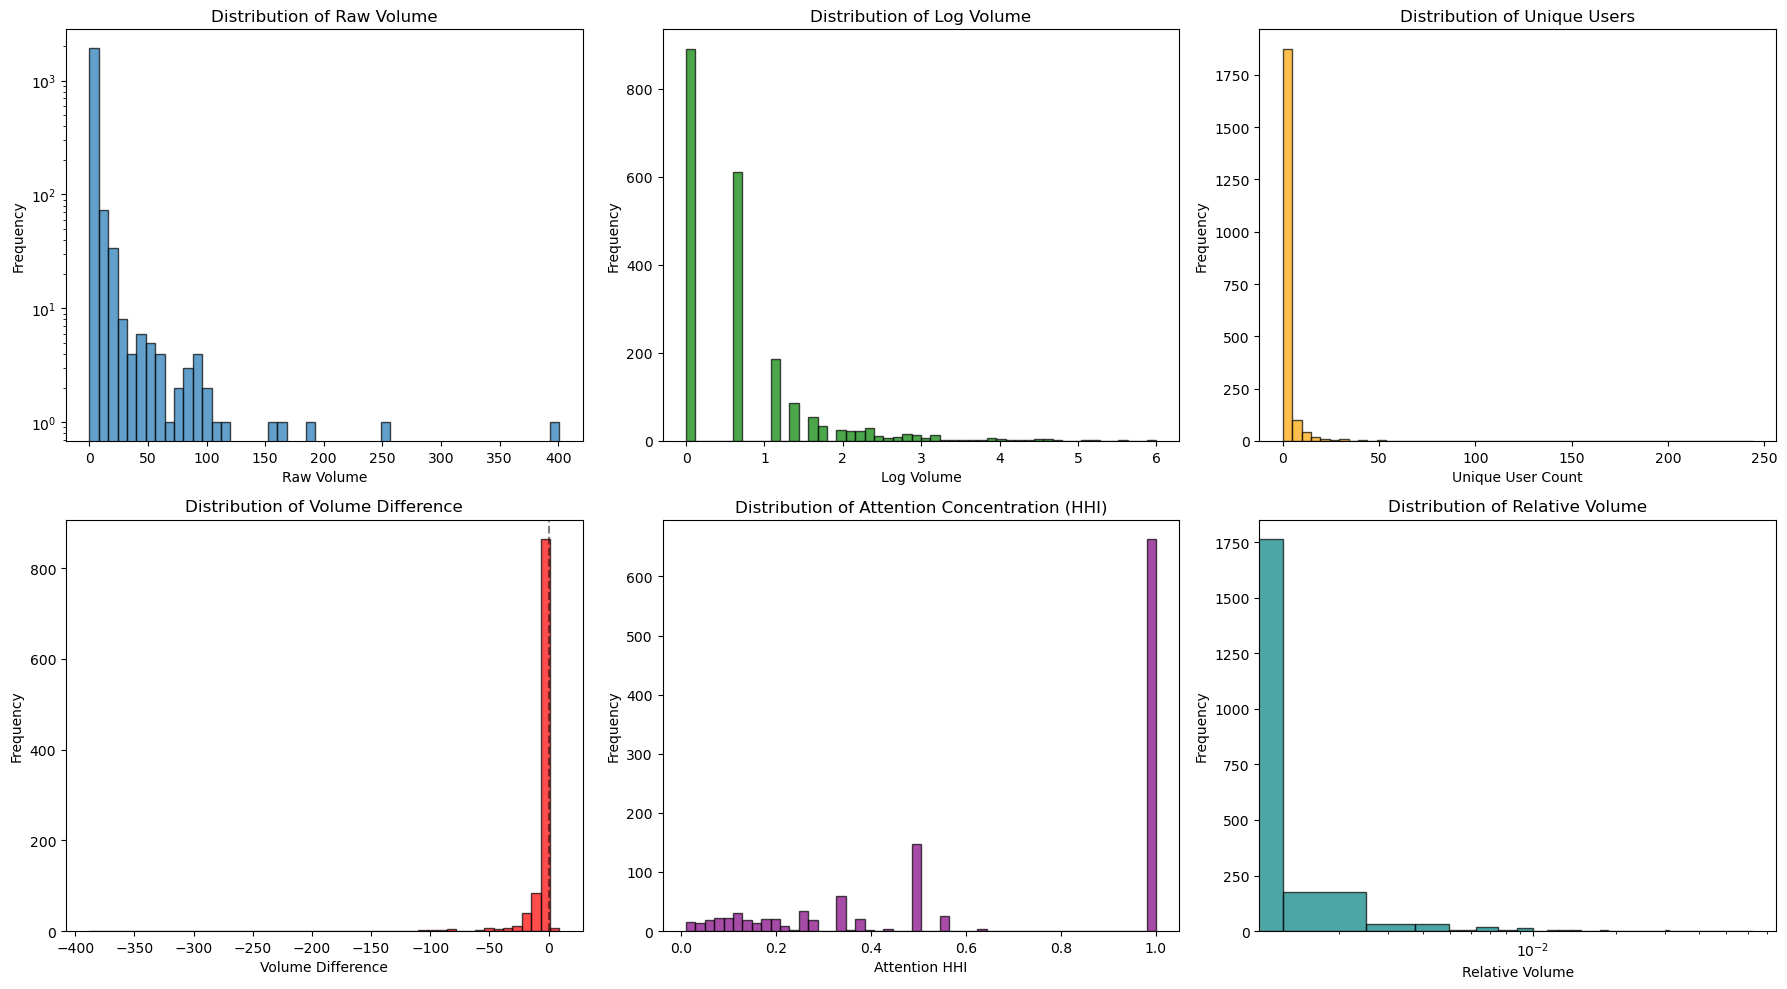


Validation Checks:
Log volume should be non-negative:
  Min: 0.000
  Max: 5.996

Relative volume should sum to 1.0 per day:
  Mean sum: 1.000000
  Min sum: 1.000000
  Max sum: 1.000000

Attention HHI should be in [0, 1]:
  Min: 0.011237
  Max: 1.000000


In [7]:
# Visualize key volume features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Raw Volume distribution
axes[0, 0].hist(features_sample['raw_volume'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Raw Volume')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Raw Volume')
axes[0, 0].set_yscale('log')

# 2. Log Volume distribution
axes[0, 1].hist(features_sample['log_volume'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].set_xlabel('Log Volume')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Log Volume')

# 3. Unique User Count
axes[0, 2].hist(features_sample['unique_user_count'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0, 2].set_xlabel('Unique User Count')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('Distribution of Unique Users')

# 4. Volume Difference
vol_diff_clean = features_sample['volume_diff'].dropna()
axes[1, 0].hist(vol_diff_clean, bins=50, edgecolor='black', alpha=0.7, color='red')
axes[1, 0].set_xlabel('Volume Difference')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Volume Difference')
axes[1, 0].axvline(0, color='black', linestyle='--', alpha=0.5)

# 5. Attention HHI
axes[1, 1].hist(features_sample['attention_hhi'], bins=50, edgecolor='black', alpha=0.7, color='purple')
axes[1, 1].set_xlabel('Attention HHI')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Attention Concentration (HHI)')

# 6. Relative Volume
axes[1, 2].hist(features_sample['relative_volume'], bins=50, edgecolor='black', alpha=0.7, color='teal')
axes[1, 2].set_xlabel('Relative Volume')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].set_title('Distribution of Relative Volume')
axes[1, 2].set_xscale('log')

plt.tight_layout()
plt.show()

# Print validation checks
print(f"\nValidation Checks:")
print(f"="*60)
print(f"Log volume should be non-negative:")
print(f"  Min: {features_sample['log_volume'].min():.3f}")
print(f"  Max: {features_sample['log_volume'].max():.3f}")

print(f"\nRelative volume should sum to 1.0 per day:")
daily_rel_vol_sum = features_sample.groupby('date')['relative_volume'].sum()
print(f"  Mean sum: {daily_rel_vol_sum.mean():.6f}")
print(f"  Min sum: {daily_rel_vol_sum.min():.6f}")
print(f"  Max sum: {daily_rel_vol_sum.max():.6f}")

print(f"\nAttention HHI should be in [0, 1]:")
print(f"  Min: {features_sample['attention_hhi'].min():.6f}")
print(f"  Max: {features_sample['attention_hhi'].max():.6f}")

## 6. Analyze Abnormal Attention Features


Horizon 5 days:
  Attention surge events: 0.00% of observations

Horizon 21 days:
  Attention surge events: 0.00% of observations

Horizon 63 days:
  Attention surge events: 0.00% of observations

Horizon 250 days:
  Attention surge events: 0.00% of observations


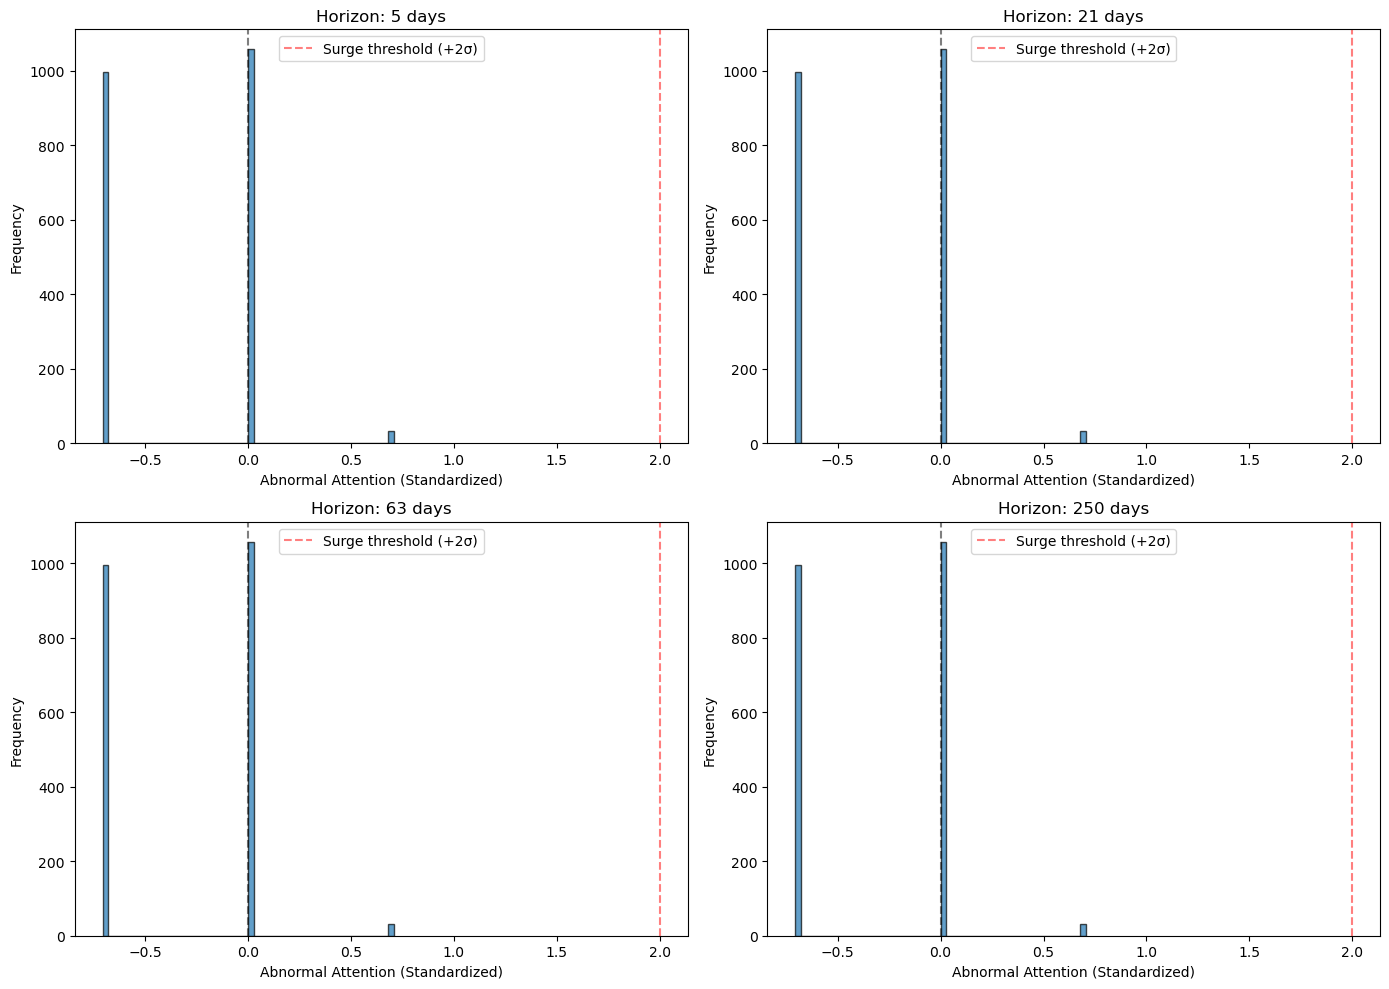

In [8]:
# Analyze abnormal attention features across horizons
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, H in enumerate(HORIZONS):
    row = idx // 2
    col = idx % 2
    
    abn_col = f'abn_attention_std_{H}d'
    surge_col = f'attention_surge_{H}d'
    
    # Plot standardized abnormal attention
    abn_data = features_sample[abn_col].dropna()
    axes[row, col].hist(abn_data, bins=50, edgecolor='black', alpha=0.7)
    axes[row, col].set_xlabel(f'Abnormal Attention (Standardized)')
    axes[row, col].set_ylabel('Frequency')
    axes[row, col].set_title(f'Horizon: {H} days')
    axes[row, col].axvline(0, color='black', linestyle='--', alpha=0.5)
    axes[row, col].axvline(2, color='red', linestyle='--', alpha=0.5, label='Surge threshold (+2σ)')
    axes[row, col].legend()
    
    # Print surge statistics
    surge_pct = features_sample[surge_col].mean() * 100
    print(f"\nHorizon {H} days:")
    print(f"  Attention surge events: {surge_pct:.2f}% of observations")

plt.tight_layout()
plt.show()

## 7. Test on Top Stocks

In [9]:
# Analyze top 5 most active stocks
top_stocks = features_sample.nlargest(5, 'raw_volume')['symbol'].unique()
print(f"Top 5 stocks by volume: {list(top_stocks)}\n")

for stock in top_stocks:
    stock_features = features_sample[features_sample['symbol'] == stock].copy()
    stock_features = stock_features.sort_values('date')
    
    print(f"\n{stock}:")
    print(f"  Mean raw volume: {stock_features['raw_volume'].mean():.1f}")
    print(f"  Mean unique users: {stock_features['unique_user_count'].mean():.1f}")
    print(f"  Mean attention HHI: {stock_features['attention_hhi'].mean():.3f}")
    print(f"  Mean relative volume: {stock_features['relative_volume'].mean():.6f}")

Top 5 stocks by volume: ['MARA', 'TSLA', 'MULN', 'AMC', 'FSR']


MARA:
  Mean raw volume: 207.0
  Mean unique users: 128.0
  Mean attention HHI: 0.050
  Mean relative volume: 0.044436

TSLA:
  Mean raw volume: 129.0
  Mean unique users: 81.0
  Mean attention HHI: 0.064
  Mean relative volume: 0.028664

MULN:
  Mean raw volume: 99.5
  Mean unique users: 62.5
  Mean attention HHI: 0.052
  Mean relative volume: 0.028660

AMC:
  Mean raw volume: 83.5
  Mean unique users: 53.0
  Mean attention HHI: 0.135
  Mean relative volume: 0.016580

FSR:
  Mean raw volume: 78.0
  Mean unique users: 44.5
  Mean attention HHI: 0.263
  Mean relative volume: 0.013610


## 8. Process All Years

In [10]:
# Process all years and concatenate
all_features = []
processing_stats = []

print(f"{'='*60}")
print(f"Processing all years...")
print(f"{'='*60}\n")

for idx, file in enumerate(tqdm(files, desc="Processing years")):
    try:
        # Load current year data
        year = file.split('_')[-1].replace('.csv', '')
        file_path = INPUT_FOLDER / file
        
        df_current = pd.read_csv(file_path)
        df_current['date'] = pd.to_datetime(df_current['date'])
        if 'created_at' in df_current.columns:
            df_current['created_at'] = pd.to_datetime(df_current['created_at'])
        
        # Load previous year data if available (for rolling window calculations)
        if idx > 0:
            prev_file = files[idx - 1]
            prev_file_path = INPUT_FOLDER / prev_file
            df_prev = pd.read_csv(prev_file_path)
            df_prev['date'] = pd.to_datetime(df_prev['date'])
            if 'created_at' in df_prev.columns:
                df_prev['created_at'] = pd.to_datetime(df_prev['created_at'])
            
            # Combine previous and current year
            df_combined = pd.concat([df_prev, df_current], ignore_index=True)
        else:
            # First year: no previous data available
            df_combined = df_current
        
        # Filter trading days to match the combined data range
        # This ensures we only create a grid for the 2 years we're processing
        if ALL_TRADING_DAYS is not None:
            data_start = df_combined['date'].min()
            data_end = df_combined['date'].max()
            filtered_trading_days = ALL_TRADING_DAYS[
                (ALL_TRADING_DAYS >= data_start) & 
                (ALL_TRADING_DAYS <= data_end)
            ]
        else:
            filtered_trading_days = None
        
        # Calculate features on combined data (with filtered trading days)
        features_combined = calculate_volume_attention_features(
            df_combined, 
            trading_days=filtered_trading_days
        )
        
        # Filter to keep only current year's results
        year_start = df_current['date'].min()
        year_end = df_current['date'].max()
        features_year = features_combined[
            (features_combined['date'] >= year_start) & 
            (features_combined['date'] <= year_end)
        ].copy()
        
        # Add to list
        all_features.append(features_year)
        
        # Track stats
        processing_stats.append({
            'year': year,
            'input_rows': len(df_current),
            'feature_rows': len(features_year),
            'unique_symbols': features_year['symbol'].nunique(),
            'unique_dates': features_year['date'].nunique()
        })
        
    except Exception as e:
        print(f"Error processing {file}: {str(e)}")

# Concatenate all years
features_all = pd.concat(all_features, ignore_index=True)

print(f"\n{'='*60}")
print(f"Processing Complete!")
print(f"{'='*60}")
print(f"\nTotal features: {len(features_all):,}")
print(f"Unique symbols: {features_all['symbol'].nunique():,}")
print(f"Date range: {features_all['date'].min()} to {features_all['date'].max()}")

# Show processing stats
df_stats = pd.DataFrame(processing_stats)
print(f"\nProcessing Statistics by Year:")
display(df_stats)

Processing all years...



Processing years:   0%|          | 0/15 [00:00<?, ?it/s]

  Creating complete trading day grid...
    Using Fama-French calendar: 149 trading days
    Symbols: 1698
    Grid size: 253,002 rows
  Calculating rolling window features...


C:\Users\skazempour\AppData\Local\Temp\ipykernel_11452\4156203445.py:85: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  volume_features['has_data'] = volume_features['has_data'].fillna(False)


  Calculating silence gaps...
  Calculating attention concentration (HHI)...
  Final feature count: 253,002 rows
  Creating complete trading day grid...
    Using Fama-French calendar: 401 trading days
    Symbols: 2711
    Grid size: 1,087,111 rows


...

C:\Users\skazempour\AppData\Local\Temp\ipykernel_11452\4156203445.py:85: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  volume_features['has_data'] = volume_features['has_data'].fillna(False)


  Calculating rolling window features...
  Calculating silence gaps...
  Calculating attention concentration (HHI)...
  Final feature count: 2,841,171 rows
  Creating complete trading day grid...
    Using Fama-French calendar: 252 trading days
    Symbols: 5223
    Grid size: 1,316,196 rows


C:\Users\skazempour\AppData\Local\Temp\ipykernel_11452\4156203445.py:85: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  volume_features['has_data'] = volume_features['has_data'].fillna(False)


  Calculating rolling window features...
  Calculating silence gaps...
  Calculating attention concentration (HHI)...
  Final feature count: 1,316,196 rows

Processing Complete!

Total features: 14,193,826
Unique symbols: 8,245
Date range: 2010-06-02 00:00:00 to 2024-01-03 00:00:00

Processing Statistics by Year:


,year,input_rows,feature_rows,unique_symbols,unique_dates
0,2010,11824,253002,1698,149
1,2011,34180,683172,2711,252
2,2012,80848,771000,3084,250
3,2013,463112,890820,3535,252
4,2014,1182579,986328,3914,252
5,2015,1635280,1033956,4103,252
6,2016,2349348,1058904,4202,252
7,2017,5109376,1062985,4235,251
8,2018,5999550,1064993,4243,251
9,2019,5994560,1069236,4243,252


## 9. Final Data Inspection

In [11]:
# Inspect final dataset
print(f"Final Features Dataset:")
print(f"="*60)
print(f"Shape: {features_all.shape}")
print(f"\nColumns: {list(features_all.columns)}")
print(f"\nData types:")
print(features_all.dtypes)
print(f"\nMemory usage: {features_all.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nNull values:")
print(features_all.isnull().sum())
print(f"\nSample data:")
display(features_all.head(20))

Final Features Dataset:
Shape: (14193826, 22)

Columns: ['symbol', 'date', 'raw_volume', 'log_volume', 'unique_user_count', 'volume_diff', 'log_volume_change', 'abn_volume_5d', 'abn_attention_std_5d', 'attention_surge_5d', 'abn_volume_21d', 'abn_attention_std_21d', 'attention_surge_21d', 'abn_volume_63d', 'abn_attention_std_63d', 'attention_surge_63d', 'abn_volume_250d', 'abn_attention_std_250d', 'attention_surge_250d', 'silence_gap_hours', 'relative_volume', 'attention_hhi']

Data types:
symbol                            object
date                      datetime64[ns]
raw_volume                       float64
log_volume                       float64
unique_user_count                float64
volume_diff                      float64
log_volume_change                float64
abn_volume_5d                    float64
abn_attention_std_5d             float64
attention_surge_5d                 int32
abn_volume_21d                   float64
abn_attention_std_21d            float64
attention_surg

,symbol,date,raw_volume,log_volume,unique_user_count,volume_diff,log_volume_change,abn_volume_5d,abn_attention_std_5d,attention_surge_5d,abn_volume_21d,abn_attention_std_21d,attention_surge_21d,abn_volume_63d,abn_attention_std_63d,attention_surge_63d,abn_volume_250d,abn_attention_std_250d,attention_surge_250d,silence_gap_hours,relative_volume,attention_hhi
0,A,2010-06-02,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0,0.0,0.0,0,0.0,0.0,0,0.0,0.0,0,NaN,0.0,NaN
1,A,2010-06-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0,0.0,0.0,0,0.0,0.0,0,NaN,0.0,NaN
2,A,2010-06-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0,0.0,0.0,0,0.0,0.0,0,NaN,0.0,NaN
3,A,2010-06-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0,0.0,0.0,0,0.0,0.0,0,NaN,0.0,NaN
4,A,2010-06-08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0,0.0,0.0,0,0.0,0.0,0,NaN,0.0,NaN
5,A,2010-06-09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0,0.0,0.0,0,0.0,0.0,0,NaN,0.0,NaN
6,A,2010-06-10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0,0.0,0.0,0,0.0,0.0,0,NaN,0.0,NaN
7,A,2010-06-11,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0,0.0,0.0,0,0.0,0.0,0,NaN,0.0,NaN
8,A,2010-06-14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0,0.0,0.0,0,0.0,0.0,0,NaN,0.0,NaN
9,A,2010-06-15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0,0.0,0.0,0,0.0,0.0,0,NaN,0.0,NaN


## 10. Save to Pickle

In [12]:
# Save features to pickle
print(f"Saving features to: {OUTPUT_FILE}")
features_all.to_pickle(OUTPUT_FILE)
print(f"✓ Saved successfully!")

# Verify save
print(f"\nVerifying saved file...")
features_loaded = pd.read_pickle(OUTPUT_FILE)
print(f"✓ File readable")
print(f"✓ Shape matches: {features_loaded.shape == features_all.shape}")
print(f"✓ Columns match: {list(features_loaded.columns) == list(features_all.columns)}")

# File size
file_size_mb = OUTPUT_FILE.stat().st_size / 1024**2
print(f"\nFile size: {file_size_mb:.2f} MB")

Saving features to: c:\Users\skazempour\Documents\StockTwits\dataset\v1\data\csv\features_mlcrowd\features_02_volume_attention.pkl
✓ Saved successfully!

Verifying saved file...
✓ File readable
✓ Shape matches: True
✓ Columns match: True

File size: 2125.22 MB


## Summary

✓ **Features Calculated:**
- Raw Volume, Log Volume, Unique User Count
- Volume Difference, Log Volume Change
- Abnormal Volume & Attention (4 horizons each)
- Attention Surge indicators (4 horizons)
- Silence Gap, Relative Volume
- Attention Concentration (HHI)

✓ **Total Feature Columns:** 8 + (3 × 4 horizons) + 3 = 23 features

✓ **Output:** `features_02_volume_attention.pkl`

✓ **Ready for:** Feature aggregation in final pipeline